# 05 — Reiknuð húsaleiga (imputed rent, Phase 4)

CP042 is the **largest CPI component (~21%)** and the hardest to model: Hagstofa
switched it from user cost (house prices + real mortgage rates) to **rental
equivalence (leiguígildi)** in June 2024, so pre-break history is a different
data-generating process and can't be estimated across (`PLAN_1.md` §1.1, §4).

**Driver data — HMS, straight from source.** HMS publishes its rental index
(leiguvísitala) and purchase-price index (kaupvísitala) as open CSVs. The rental
index measures **new-contract, capital-area rents** — a leading, noisier signal
for Hagstofa's **nationwide, stock-based** measure. They are not substitutes; the
model is the explicit distributed lag between them.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}" if abs(x) < 1e6 else f"{x:,.0f}")

# Okabe-Ito palette (colorblind-safe); recessive grid per house chart style
C = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
     "red": "#D55E00", "pink": "#CC79A7", "sky": "#56B4E9", "black": "#222222"}
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})


In [2]:
from vnv import hms, ingest, models, rent

rent_idx = hms.load_rent()
house = hms.load_house()
spl = ingest.load_sub_spliced()
cp042_lvl = spl[spl.code == "CP042"].set_index("manudur").visitala

print("HMS rental index:", rent_idx.index.min(), "-", rent_idx.index.max())
print("HMS house price:  ", house.index.min(), "-", house.index.max())
print("CP042 (target):   ", cp042_lvl.index.min(), "-", cp042_lvl.index.max())


HMS rental index: 2023-05 - 2026-07
HMS house price:   2020-01 - 2026-07
CP042 (target):    1997-03 - 2026-07


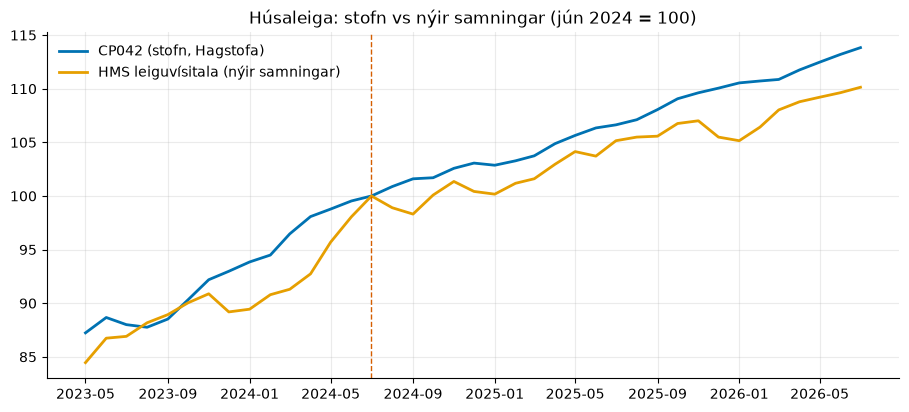

The stock is far smoother than the flow — the modelling problem in one picture.


In [3]:
# Levels rebased to the June-2024 break: stock (CP042) vs new-contract flow (HMS)
base = pd.Period("2024-07", "M")
lv = pd.DataFrame({
    "CP042 (stofn, Hagstofa)": cp042_lvl / cp042_lvl[base] * 100,
    "HMS leiguvísitala (nýir samningar)": rent_idx.leiguvisitala / rent_idx.leiguvisitala[base] * 100,
}).dropna()
fig, ax = plt.subplots()
ax.plot(lv.index.to_timestamp(), lv.iloc[:, 0], color=C["blue"], lw=2, label=lv.columns[0])
ax.plot(lv.index.to_timestamp(), lv.iloc[:, 1], color=C["orange"], lw=2, label=lv.columns[1])
ax.axvline(base.to_timestamp(), color=C["red"], ls="--", lw=1)
ax.set_title("Húsaleiga: stofn vs nýir samningar (jún 2024 = 100)")
ax.legend(frameon=False, loc="upper left")
plt.show()
print("The stock is far smoother than the flow — the modelling problem in one picture.")


## The distributed lag

New-contract rents lead the stock. Contemporaneous correlation is ~0; the signal
shows up at **lags 1–3**, and — crucially — HMS releases month *t* in *t+1*, so
those lags are all **observable** when a month-*t* forecast is made. No look-ahead.


In [4]:
cp042_mm = rent.load_cp042_history(spl)
hms_mm = rent.hms_rent_mm()
post = pd.concat([cp042_mm.rename("stofn"), hms_mm.rename("nýir")], axis=1)
post = post[post.index >= rent.BREAK].dropna()

corrs = {f"lag {k}": post.stofn.corr(post["nýir"].shift(k)) for k in range(5)}
print("corr(CP042 m/m, HMS m/m at lag k), post-break:")
for k, v in corrs.items():
    print(f"  {k}: {v:+.3f}")


corr(CP042 m/m, HMS m/m at lag k), post-break:
  lag 0: -0.079
  lag 1: +0.423
  lag 2: +0.319
  lag 3: -0.276
  lag 4: -0.083


## Model and the Phase 4 acceptance test

Shipped model (chosen by an out-of-sample horse race, post-break sample only):

$$\text{CP042 m/m}_t = 0.7\,\underbrace{\text{EWMA}_{hl=6}(\text{CP042 m/m})}_{\text{stock persistence}}
+ 0.3\,\underbrace{(a + b\cdot \overline{\text{HMS m/m}}_{t-1..t-3})}_{\text{new-contract tilt}}$$

The 0.3 tilt is deliberate shrinkage — with ~25 post-break months the HMS slope
is real but weak, so it nudges the drift at turning points without a short noisy
regression taking over. **Acceptance criterion: OOS m/m must beat random walk and
AR(1).**


In [5]:
rows = []
for i in range(6, len(post)):
    m = post.index[i]
    hist_y = cp042_mm[cp042_mm.index <= post.index[i - 1]]
    hist_h = hms_mm[hms_mm.index <= post.index[i - 1]]
    fcv = rent.forecast_cp042(hist_y, hist_h, post.index[i - 1], horizons=1).iloc[0]
    tr = post.stofn.iloc[:i]; yy = tr.values
    ar1 = (np.polyval(np.polyfit(yy[:-1], yy[1:], 1), tr.iloc[-1])
           if len(yy) > 3 and np.var(yy[:-1]) > 0 else tr.mean())
    rows.append({"manudur": m, "actual": post.stofn.iloc[i], "HMS model": fcv,
                 "random walk": tr.iloc[-1], "AR(1)": ar1})
bt = pd.DataFrame(rows).set_index("manudur").dropna()
stats = pd.DataFrame({c: {"RMSE": np.sqrt(((bt[c] - bt.actual) ** 2).mean()),
                          "MAE": (bt[c] - bt.actual).abs().mean()}
                      for c in ["HMS model", "random walk", "AR(1)"]}).T
gate = stats.loc["HMS model", "RMSE"] < stats.loc[["random walk", "AR(1)"], "RMSE"].min()
print("PHASE 4 ACCEPTANCE:", "PASS ✅" if gate else "FAIL ❌",
      f"(n={len(bt)} post-break OOS months)")
stats.round(4)


PHASE 4 ACCEPTANCE: PASS ✅ (n=19 post-break OOS months)


,RMSE,MAE
HMS model,0.3097,0.2401
random walk,0.3616,0.2767
AR(1),0.3388,0.2636


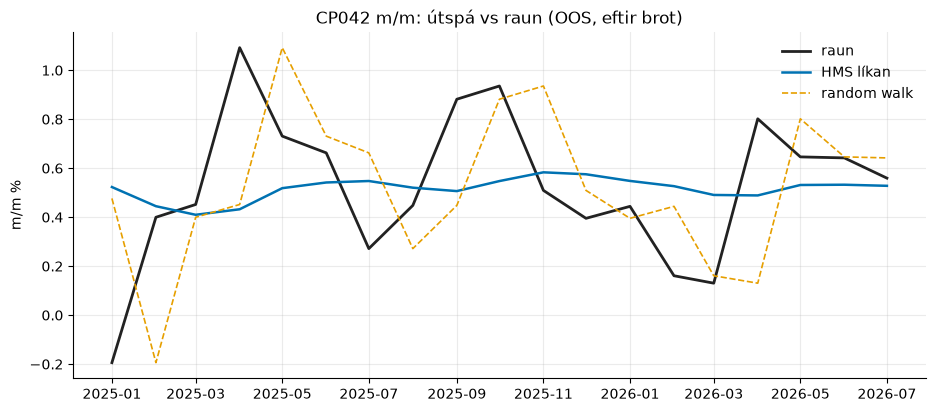

In [6]:
fig, ax = plt.subplots()
ax.plot(bt.index.to_timestamp(), bt.actual, color=C["black"], lw=2, label="raun")
ax.plot(bt.index.to_timestamp(), bt["HMS model"], color=C["blue"], lw=1.8, label="HMS líkan")
ax.plot(bt.index.to_timestamp(), bt["random walk"], color=C["orange"], lw=1.2, ls="--", label="random walk")
ax.set_title("CP042 m/m: útspá vs raun (OOS, eftir brot)")
ax.set_ylabel("m/m %"); ax.legend(frameon=False)
plt.show()


## Regime break: why post-break only (reported, not shipped)

The plan asks to also fit the full sample with a regime dummy and justify the
choice. The interaction term shows the HMS slope **flips sign** across the break
and the level shifts down — the two regimes are genuinely different processes, so
a long-sample model would inherit the old user-cost dynamics. Post-break-only is
correct.


In [7]:
full = pd.concat([cp042_mm.rename("y"), rent._hms_driver(hms_mm).rename("x")], axis=1).dropna()
full["post"] = (full.index >= rent.BREAK).astype(float)
X = np.column_stack([np.ones(len(full)), full.x, full.post, full.x * full.post])
beta, *_ = np.linalg.lstsq(X, full.y.values, rcond=None)
print(f"pre-break slope on HMS driver:  {beta[1]:+.3f}")
print(f"post-break slope on HMS driver: {beta[1] + beta[3]:+.3f}")
print(f"post-break level shift (dummy): {beta[2]:+.3f} pp/month")
print("-> different regimes; estimating across the break would corrupt the model.")


pre-break slope on HMS driver:  -0.149
post-break slope on HMS driver: +0.133
post-break level shift (dummy): -0.936 pp/month
-> different regimes; estimating across the break would corrupt the model.


## What this means for the 12-month path

Under rental equivalence the stock turns over slowly, so CP042 is now **more
persistent and more forecastable** than house prices were under user cost — and
headline inflation is correspondingly **less policy-rate sensitive** than pre-2024
history implies (`PLAN_1.md` §4). The path carries the EWMA drift forward, tilted
at h=1 by the latest observable HMS reading; beyond h=1 the HMS lags are unknown,
so persistence governs.


In [8]:
last_m = cp042_mm.index.max()
path = rent.forecast_cp042(cp042_mm, hms_mm, last_m, horizons=12)
lvl_path = cp042_lvl.iloc[-1] * (1 + path / 100).cumprod()
print(f"jump-off {last_m}: CP042 12-month path")
print(f"implied 12m rent inflation: {((1 + path / 100).prod() - 1) * 100:.2f}%  "
      f"(h=1 carries the HMS tilt: {path.iloc[0]:+.3f}%, then EWMA drift {path.iloc[-1]:+.3f}%)")
out = pd.DataFrame({"m/m spá (%)": path.round(3), "index (spá)": lvl_path.round(1)})
out


jump-off 2026-07: CP042 12-month path
implied 12m rent inflation: 6.61%  (h=1 carries the HMS tilt: +0.527%, then EWMA drift +0.535%)


,m/m spá (%),index (spá)
2026-08,0.5270,"1,030.1000"
2026-09,0.5350,"1,035.6000"
2026-10,0.5350,"1,041.2000"
2026-11,0.5350,"1,046.7000"
2026-12,0.5350,"1,052.3000"
2027-01,0.5350,"1,058.0000"
2027-02,0.5350,"1,063.6000"
2027-03,0.5350,"1,069.3000"
2027-04,0.5350,"1,075.1000"
2027-05,0.5350,"1,080.8000"


### Phase 4 status

Rent model **live and integrated**: `models.forecast_components(..., hms_rent_mm=,
sub_spliced=)` routes CP042 through it, so notebook 03's headline forecast and the
dashboard both use it. HMS data auto-loads from source (cached); `hms.snapshot()`
accrues true input vintages going forward for a fully vintage-clean backtest.

Remaining plan work: Phase 6 (BVAR top-down + MinT reconciliation), Phase 7
(analyst / Seðlabanki / breakeven benchmark table).
